<a href="https://colab.research.google.com/github/reezyhudson865/AI_Projects/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Challenge Lab: News Topic Classification with LSTM
**Course:** AI 102: Natural Language-based Programming Techniques  
- **Name:** Reezy Hudson
- **NetID:** rhudso10  
- **Section:** 002  
---


In [ ]:
import tensorflow as tf
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

GPU: []


In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import reuters
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


def load_reuters_grouped():
    """
    Load Reuters and group the 46 topics into 5 balanced themes.
    """
    MAX_VOCAB = 5000
    (X_tr, y_tr), (X_te, y_te) = reuters.load_data(num_words=MAX_VOCAB)


    theme_map = {}
    for label in [3]:
        theme_map[label] = 0  # EARNINGS
    for label in [4]:
        theme_map[label] = 1  # ACQUISITIONS
    for label in [8, 12, 19, 20, 40]:
        theme_map[label] = 2  # FINANCE
    for label in [0, 1, 2, 5, 6, 9, 10, 14, 15, 16, 17, 22, 23, 24, 25, 26, 27, 28, 31, 32, 33, 37, 38, 39, 41, 42, 44, 45]:
        theme_map[label] = 3  # COMMODITIES
    for label in [7, 11, 13, 18, 21, 29, 30, 34, 35, 36, 43]:
        theme_map[label] = 4  # ECONOMY

    topic_names = ['earnings', 'acquisitions', 'finance', 'commodities', 'economy']
    NUM_CLASSES = 5

    train_idx = [i for i, y in enumerate(y_tr) if y in theme_map]
    test_idx  = [i for i, y in enumerate(y_te) if y in theme_map]

    X_train = [X_tr[i] for i in train_idx]
    X_test  = [X_te[i] for i in test_idx]

    y_train = np.array([theme_map[y_tr[i]] for i in train_idx])
    y_test  = np.array([theme_map[y_te[i]] for i in test_idx])

    return X_train, y_train, X_test, y_test, topic_names, MAX_VOCAB, NUM_CLASSES


X_train_raw, y_train_mapped, X_test_raw, y_test_mapped, topic_names, MAX_VOCAB, NUM_CLASSES = load_reuters_grouped()

print(f'Dataset loaded successfully!')
print(f'  Training articles: {len(X_train_raw)}')
print(f'  Test articles:     {len(X_test_raw)}')
print(f'  Vocabulary size:   {MAX_VOCAB}')
print(f'  Number of topics:  {NUM_CLASSES}')
print()
print(f'{"Topic":<15} {"Train":<8} {"Test"}')
print('-' * 30)
for i, name in enumerate(topic_names):
    train_count = int(np.sum(y_train_mapped == i))
    test_count = int(np.sum(y_test_mapped == i))
    print(f'  {name:<15} {train_count:<8} {test_count}')

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
Dataset loaded successfully!
  Training articles: 8982
  Test articles:     2246
  Vocabulary size:   5000
  Number of topics:  5

Topic           Train    Test
------------------------------
  earnings        3159     813
  acquisitions    1949     474
  finance         1042     264
  commodities     1894     479
  economy         938      216


First article (first 15 words as numbers):
  [1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16]
  Each number represents a word. Keras already did the tokenization for us.
  Topic label: earnings

Shortest article: 13 words
Longest article:  2376 words
Average length:   145 words
Median length:    95 words



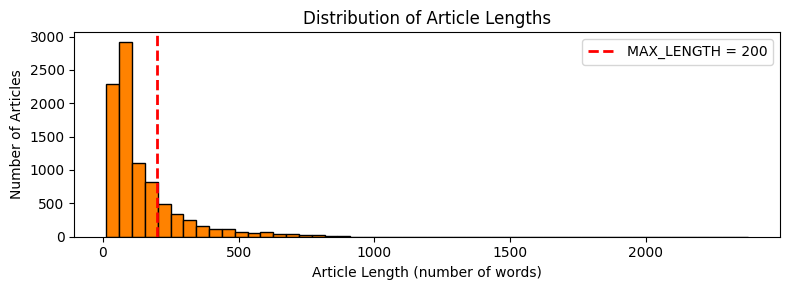

79.1% of articles are 200 words or shorter.
Setting MAX_LENGTH=200 captures most articles without wasting memory on padding.


In [ ]:
print('First article (first 15 words as numbers):')
print(f'  {list(X_train_raw[0][:15])}')
print(f'  Each number represents a word. Keras already did the tokenization for us.')
print(f'  Topic label: {topic_names[y_train_mapped[0]]}')
print()

lengths = [len(x) for x in X_train_raw]
print(f'Shortest article: {min(lengths)} words')
print(f'Longest article:  {max(lengths)} words')
print(f'Average length:   {sum(lengths) // len(lengths)} words')
print(f'Median length:    {sorted(lengths)[len(lengths)//2]} words')
print()


plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=50, color='#FF8200', edgecolor='black')
plt.axvline(x=200, color='red', linestyle='--', linewidth=2, label='MAX_LENGTH = 200')
plt.xlabel('Article Length (number of words)')
plt.ylabel('Number of Articles')
plt.title('Distribution of Article Lengths')
plt.legend()
plt.tight_layout()
plt.show()


pct = sum(1 for l in lengths if l <= 200) / len(lengths) * 100
print(f'{pct:.1f}% of articles are 200 words or shorter.')
print('Setting MAX_LENGTH=200 captures most articles without wasting memory on padding.')

## 3. Pad Sequences

Articles have different lengths. Neural networks need fixed-size inputs. Use `pad_sequences` to make all articles the same length.

**Hint:** `pad_sequences(data, maxlen=____)`

In [ ]:
MAX_LENGTH = 200

X_train = pad_sequences(X_train_raw, maxlen=MAX_LENGTH)

X_test = pad_sequences(X_test_raw, maxlen=MAX_LENGTH)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

X_train shape: (8982, 200)
X_test shape:  (2246, 200)


In [ ]:
y_train = to_categorical(y_train_mapped, num_classes=NUM_CLASSES)

y_test = to_categorical(y_test_mapped, num_classes=NUM_CLASSES)

print(f'y_train shape: {y_train.shape}')
print(f'Example: label {y_train_mapped[0]} → {y_train[0]}')

y_train shape: (8982, 5)
Example: label 0 → [1. 0. 0. 0. 0.]


In [ ]:
model = Sequential()

model.add(Input(shape=(MAX_LENGTH,)))

model.add(Embedding(input_dim=MAX_VOCAB, output_dim=64))

model.add(LSTM(128, return_sequences=True))

model.add(Dropout(0.3))

model.add(LSTM(64))

model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(NUM_CLASSES, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 470,469 (1.79 MB)

 Trainable params: 470,469 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    verbose=1,
    validation_data=(X_test, y_test)
)

Epoch 1/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 145s 494ms/step - accuracy: 0.6330 - loss: 0.9334 - val_accuracy: 0.7168 - val_loss: 0.7647
Epoch 2/5
281/281 ━━━━━━━━━━━━━━━━━━━━ 126s 447ms/step - accuracy: 0.7688 - loss: 0.6825 - val_accuracy: 0.7983 - val_loss: 0.6496
Epoch 3/5
254/281 ━━━━━━━━━━━━━━━━━━━━ 11s 442ms/step - accuracy: 0.8372 - loss: 0.5498

In [ ]:
y_pred_probs = model.predict(X_test)

y_pred_classes = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test_mapped, y_pred_classes)
print(f'Overall Accuracy: {accuracy:.4f}')
print()

print('Per-Topic Performance:')
print(classification_report(y_test_mapped, y_pred_classes,
                            target_names=topic_names, digits=3))

In [ ]:
cm = confusion_matrix(y_test_mapped, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=topic_names)
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy Over Epochs')
plt.grid(True)
plt.show()